# World Cup Score Probability Model: Step 1 - Data Preparation
This notebook prepares historical international football data for a statistical predictive model (e.g., Poisson Regression or Bayesian Hierarchical Model). 

**Data Source:** Download the `results.csv` dataset from Kaggle (Search: "International football results from 1872 to [Current Year]" by Mart Jürisoo) and place it in the same directory as this notebook.

In [1]:
import pandas as pd
import numpy as np
import os
import requests
from pathlib import Path

# Set pandas display options to easily inspect our data later
pd.set_option('display.max_columns', None)
# 1. Define the URL for the raw dataset
# This points directly to the author's continuous updates on GitHub, bypassing Kaggle API limits
dataset_url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

# 2. Set up the directory structure
# This creates a 'data' folder in your current working directory if it doesn't already exist
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

# Define the exact path where the file will be saved
file_path = data_dir / "results.csv"

# 3. Download and save the dataset
print("Downloading dataset...")
response = requests.get(dataset_url)

# Check if the download was successful
if response.status_code == 200:
    with open(file_path, 'wb') as file:
        file.write(response.content)
    print(f"Success! Dataset saved to: {file_path.absolute()}")
else:
    print(f"Failed to download the dataset. HTTP Status Code: {response.status_code}")

Success! Dataset saved to: /Users/davidpardo/Programming/world-cup-scores/data/results.csv


## 1. Load and Filter the Data
Football has changed drastically over the decades. Matches played in the 1930s or 1950s will introduce noise rather than signal. We will filter the dataset to only include matches from the last 50 years.

In [2]:
from src.data import prepare_matches

data_config = {"years": 50, "exclude_friendlies": True}
arrays = prepare_matches(data_config, file_path)

df = arrays.df
home_team_array = arrays.home_team_array
away_team_array = arrays.away_team_array
home_goals_array = arrays.home_goals_array
away_goals_array = arrays.away_goals_array
team_to_id = arrays.team_to_id
id_to_team = arrays.id_to_team
all_teams = np.array(sorted(team_to_id.keys()))
num_teams = arrays.num_teams

print(f"Matches: {arrays.n_matches} (dropped {arrays.n_dropped_missing_scores} with missing scores)")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1906-08-15,Uruguay,Argentina,0.0,2.0,Copa Lipton,Montevideo,Uruguay,False
1,1906-10-21,Argentina,Uruguay,2.0,1.0,Copa Newton,Buenos Aires,Argentina,False
2,1907-02-16,England,Northern Ireland,1.0,0.0,British Home Championship,Liverpool,England,False
3,1907-02-23,Northern Ireland,Wales,2.0,3.0,British Home Championship,Belfast,Ireland,False
4,1907-03-04,Wales,Scotland,1.0,0.0,British Home Championship,Wrexham,Wales,False


## 2. Create Numerical IDs for Teams
Statistical models cannot perform math on strings like "Brazil" or "Japan". We need to map every unique team name to a specific integer index.

In [3]:
# Team IDs were created in the load step (see src/data.py)
print(f"Total unique teams registered: {num_teams}")

Total unique teams registered: 313


## 3. Extract the Modeling Arrays
Most modeling libraries (like PyMC or standard Scipy optimization) require clean 1D arrays of our parameters and outcomes. We will extract the exact arrays needed to build our Poisson distributions.

In [4]:
# Extract the team ID arrays
home_team_array = df['home_team_id'].values
away_team_array = df['away_team_id'].values

# Extract the observed outcome arrays (goals scored)
home_goals_array = df['home_score'].values
away_goals_array = df['away_score'].values

# Check the shapes to ensure everything aligns perfectly
print(f"Home Teams Array Shape: {home_team_array.shape}")
print(f"Away Teams Array Shape: {away_team_array.shape}")
print(f"Home Goals Array Shape: {home_goals_array.shape}")
print(f"Away Goals Array Shape: {away_goals_array.shape}")

Home Teams Array Shape: (30934,)
Away Teams Array Shape: (30934,)
Home Goals Array Shape: (30934,)
Away Goals Array Shape: (30934,)


## 4. Sanity Check
Let's look at a random match to ensure our ID mapping and goal extractions line up perfectly with the original data.

In [5]:
# Pick a random index
test_idx = 1000 

home_name = id_to_team[home_team_array[test_idx]]
away_name = id_to_team[away_team_array[test_idx]]
home_g = home_goals_array[test_idx]
away_g = away_goals_array[test_idx]
date = df['date'].iloc[test_idx].strftime('%Y-%m-%d')

print(f"Match at index {test_idx}:")
print(f"Date: {date}")
print(f"{home_name} (ID: {home_team_array[test_idx]}) {home_g} - {away_g} {away_name} (ID: {away_team_array[test_idx]})")

Match at index 1000:
Date: 1943-07-10
Paraguay (ID: 207) 2.0 - 5.0 Argentina (ID: 12)


## 5. Building the Bayesian Poisson Model (PyMC)
We will now use PyMC to build our probabilistic model. We are assigning an `attack` and `defense` parameter to every single team, plus a `home_advantage` parameter to account for the historical edge home teams have (even though World Cups are mostly neutral, this balances our historical training data).

**The Math:**
Expected Home Goals ($\lambda_{home}$) = $\exp(\text{Home Advantage} + \text{Home Attack} - \text{Away Defense})$
Expected Away Goals ($\lambda_{away}$) = $\exp(\text{Away Attack} - \text{Home Defense})$

In [8]:
# macOS fix: configure PyTensor C compiler before importing PyMC
import pytensor_macos

import pymc as pm
import arviz as az
import scipy.stats as stats
import matplotlib.pyplot as plt

from src.models import build_poisson_model

model_config = {
    "model": {
        "home_advantage": True,
        "attack_sigma": 1.5,
        "defense_sigma": 1.5,
    },
    "sample": {
        "draws": 2000,
        "tune": 1000,
        "chains": 4,
        "cores": 2,
        "target_accept": 0.9,
    },
}

basic_poisson_model = build_poisson_model(model_config, arrays)

print("Starting MCMC Sampling. This may take a few minutes...")
trace = pm.sample(model=basic_poisson_model, **model_config["sample"])
trace = pm.compute_log_likelihood(trace, model=basic_poisson_model)
print("Sampling complete!")

/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in home_goals contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in away_goals contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning

Starting MCMC Sampling. This may take a few minutes...


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [attack, defense, home_advantage]
>CompoundStep
>>Metropolis: [home_goals_unobserved]
>>Metropolis: [away_goals_unobserved]


/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 721 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling complete!


## 6. Inspecting the Posteriors
The MCMC algorithm has generated thousands of plausible values for every team's strength. Let's extract those distributions and look at a few top teams to see how the model rates them.

AttributeError: module 'arviz' has no attribute 'plot_kde'

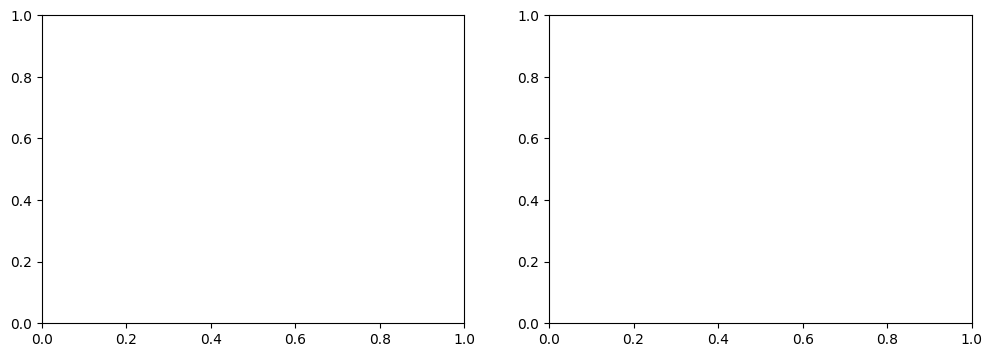

In [9]:
# Extract the posterior samples for attack and defense
posterior_attack = trace.posterior["attack"].values.reshape(-1, num_teams)
posterior_defense = trace.posterior["defense"].values.reshape(-1, num_teams)

def plot_kde_1d(samples, ax, alpha=0.5):
    """KDE on a matplotlib axis (replaces removed arviz.plot_kde in ArviZ 1.x)."""
    kde = stats.gaussian_kde(samples)
    x = np.linspace(samples.min(), samples.max(), 200)
    y = kde(x)
    ax.fill_between(x, y, alpha=alpha)
    ax.plot(x, y)

def plot_team_posterior(team_name):
    team_id = team_to_id[team_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Attack
    plot_kde_1d(posterior_attack[:, team_id], ax=axes[0], alpha=0.5)
    axes[0].set_title(f"{team_name} - Attack Strength (Higher is better)")
    axes[0].axvline(0, color='red', linestyle='--') # Baseline
    
    # Plot Defense
    plot_kde_1d(posterior_defense[:, team_id], ax=axes[1], alpha=0.5)
    axes[1].set_title(f"{team_name} - Defense Strength (Higher is better at conceding)")
    axes[1].axvline(0, color='red', linestyle='--') # Baseline
    
    plt.tight_layout()
    plt.show()

# Feel free to change these names to any team in the id_to_team dictionary
plot_team_posterior("Brazil")
plot_team_posterior("France")

## 7. Predicting a Match Score (The Probability Matrix)
To predict a future match (e.g., in a World Cup), we take the thousands of simulated attack and defense parameters from our trace, calculate the expected goals for both teams, and generate a matrix of exact score probabilities using the Poisson probability mass function.

In [10]:
def predict_match(home_team, away_team, max_goals=5, neutral_venue=True):
    home_id = team_to_id[home_team]
    away_id = team_to_id[away_team]
    
    # Get all posterior samples for these specific teams
    h_attack = posterior_attack[:, home_id]
    h_defense = posterior_defense[:, home_id]
    a_attack = posterior_attack[:, away_id]
    a_defense = posterior_defense[:, away_id]
    
    # Get home advantage samples (set to 0 if playing at a neutral World Cup venue)
    h_adv = trace.posterior["home_advantage"].values.flatten()
    if neutral_venue:
        h_adv = np.zeros_like(h_adv)
        
    # Calculate Expected Goals (Lambda) across all MCMC samples
    home_lambda = np.exp(h_adv + h_attack - a_defense)
    away_lambda = np.exp(a_attack - h_defense)
    
    # Average the lambdas to get the final point estimate for Expected Goals
    mean_home_lambda = home_lambda.mean()
    mean_away_lambda = away_lambda.mean()
    
    # Generate the Probability Matrix
    prob_matrix = np.zeros((max_goals+1, max_goals+1))
    
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            # Probability of home scoring 'i' goals * away scoring 'j' goals
            prob_home = stats.poisson.pmf(i, mean_home_lambda)
            prob_away = stats.poisson.pmf(j, mean_away_lambda)
            prob_matrix[i, j] = prob_home * prob_away
            
    # Calculate Win / Draw / Loss aggregates
    home_win = np.tril(prob_matrix, -1).sum()
    draw = np.trace(prob_matrix)
    away_win = np.triu(prob_matrix, 1).sum()
    
    # Print the results nicely
    print(f"--- PREDICTION: {home_team} vs {away_team} ---")
    print(f"Expected Goals: {home_team} {mean_home_lambda:.2f} - {mean_away_lambda:.2f} {away_team}\n")
    
    print(f"{home_team} Win: {home_win*100:.1f}%")
    print(f"Draw: {draw*100:.1f}%")
    print(f"{away_team} Win: {away_win*100:.1f}%\n")
    
    print("Exact Score Probabilities (Top 5):")
    
    # Flatten and sort the matrix to find the most likely scores
    flat_matrix = prob_matrix.flatten()
    top_indices = flat_matrix.argsort()[-5:][::-1]
    
    for idx in top_indices:
        h_goals = idx // (max_goals + 1)
        a_goals = idx % (max_goals + 1)
        print(f"{h_goals} - {a_goals} : {prob_matrix[h_goals, a_goals]*100:.1f}%")

# Test a prediction (e.g., a World Cup Final scenario on neutral ground)
predict_match("Argentina", "France", neutral_venue=True)

--- PREDICTION: Argentina vs France ---
Expected Goals: Argentina 1.16 - 1.10 France

Argentina Win: 36.9%
Draw: 28.7%
France Win: 34.2%

Exact Score Probabilities (Top 5):
1 - 1 : 13.3%
1 - 0 : 12.1%
0 - 1 : 11.5%
0 - 0 : 10.5%
2 - 1 : 7.7%


In [ ]:
# Run a tracked experiment (example: quick_test or baseline)
# from pathlib import Path
# from src.experiments import run_experiment
#
# run_id = run_experiment(Path("experiments/configs/baseline.yaml"))
# print(f"Logged to MLflow run_id={run_id}")
# Then: mlflow ui  OR  open notebooks/compare_experiments.ipynb

## 8. Confederation Mapping

In [ ]:
# 1. Define the master confederation dictionary
confed_mapping = {
    'CONMEBOL': [
        'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 
        'Paraguay', 'Peru', 'Uruguay', 'Venezuela'
    ],
    'UEFA': [
        'Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 
        'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 
        'England', 'Estonia', 'Faroe Islands', 'Finland', 'France', 'Georgia', 'Germany', 
        'Greece', 'Hungary', 'Iceland', 'Israel', 'Italy', 'Kazakhstan', 'Kosovo', 'Latvia', 
        'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro', 
        'Netherlands', 'North Macedonia', 'Northern Ireland', 'Norway', 'Poland', 'Portugal', 
        'Republic of Ireland', 'Romania', 'Russia', 'San Marino', 'Scotland', 'Serbia', 
        'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'Ukraine', 'Wales'
    ],
    'CONCACAF': [
        'Anguilla', 'Antigua and Barbuda', 'Aruba', 'Bahamas', 'Barbados', 'Belize', 'Bermuda', 
        'British Virgin Islands', 'Canada', 'Cayman Islands', 'Costa Rica', 'Cuba', 'Curaçao', 
        'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala', 'Guyana', 'Haiti', 
        'Honduras', 'Jamaica', 'Mexico', 'Montserrat', 'Nicaragua', 'Panama', 'Puerto Rico', 
        'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Suriname', 
        'Trinidad and Tobago', 'Turks and Caicos Islands', 'United States', 'US Virgin Islands'
    ],
    'CAF': [
        'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Cape Verde', 
        'Central African Republic', 'Chad', 'Comoros', 'Congo', 'DR Congo', 'Djibouti', 'Egypt', 
        'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 
        'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 
        'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 
        'Rwanda', 'São Tomé and Príncipe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 
        'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
    ],
    'AFC': [
        'Afghanistan', 'Australia', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei', 'Cambodia', 'China PR', 
        'Chinese Taipei', 'Guam', 'Hong Kong', 'India', 'Indonesia', 'Iran', 'Iraq', 'Japan', 'Jordan', 
        'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Macau', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 
        'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 
        'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Tajikistan', 'Thailand', 'Timor-Leste', 
        'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'
    ],
    'OFC': [
        'American Samoa', 'Cook Islands', 'Fiji', 'New Caledonia', 'New Zealand', 'Papua New Guinea', 
        'Samoa', 'Solomon Islands', 'Tahiti', 'Tonga', 'Vanuatu'
    ]
}

# 2. Add Historical Projections (dissolved nations mapped to modern confederations)
historical_projections = {
    'Soviet Union': 'UEFA',
    'Yugoslavia': 'UEFA',
    'Czechoslovakia': 'UEFA',
    'German DR': 'UEFA', # East Germany
    'Serbia and Montenegro': 'UEFA',
    'CIS': 'UEFA', # Commonwealth of Independent States (played in Euro 1992)
    'Zaire': 'CAF', # Modern day DR Congo
    'Netherlands Antilles': 'CONCACAF', # Dissolved in 2010
    'Yemen DPR': 'AFC', # South Yemen
    'Vietnam Republic': 'AFC' # South Vietnam
}

# 3. Flatten the dictionary so we can look up Confederation by Team Name
team_to_confed_name = {}
for confed, teams in confed_mapping.items():
    for team in teams:
        team_to_confed_name[team] = confed

# Merge the historical projections in
team_to_confed_name.update(historical_projections)

# 4. Create Integer IDs for the Confederations (PyMC requirement)
confeds = ['UEFA', 'CONMEBOL', 'CONCACAF', 'CAF', 'AFC', 'OFC', 'Other']
confed_to_id = {confed: i for i, confed in enumerate(confeds)}

# 5. Map the dataset 
def get_confed_id(team_name):
    # Try to find the exact name, otherwise assign to 'Other' (ID: 6)
    c_name = team_to_confed_name.get(team_name, 'Other')
    return confed_to_id[c_name]

# Apply mapping to our unique list of all teams
# We create an array where the index matches the team_id, and the value is their confed_id
team_confed_array = np.array([get_confed_id(id_to_team[i]) for i in range(num_teams)])

# 6. Sanity Check: Let's see how many teams fell into the "Other" category
unmapped_teams = [id_to_team[i] for i in range(num_teams) if team_confed_array[i] == confed_to_id['Other']]

print(f"Successfully mapped {num_teams - len(unmapped_teams)} out of {num_teams} teams.")
print(f"Number of unmapped teams assigned to 'Other': {len(unmapped_teams)}")

# Optional: Print a few unmapped teams to see if any major ones need manual dictionary spelling fixes
if len(unmapped_teams) > 0:
    print("\nSample of 'Other' teams (mostly tiny non-FIFA islands or spelling variants):")
    print(unmapped_teams[:15])


## 9. Historical Elo Rating Engine

In [ ]:
# 1. Initialize an Elo dictionary for all teams
# Standard Elo starts at 1500 for everyone
elo_dict = {team_id: 1500.0 for team_id in range(num_teams)}

# 2. Define the K-factor (Match Importance Weight) mapping
def get_k_factor(tournament):
    if 'FIFA World Cup' in tournament and 'Qualification' not in tournament:
        return 60  # Highest stakes
    elif 'Continental' in tournament or 'Copa America' in tournament or 'Euro' in tournament:
        return 40  # Major continental tournaments
    elif 'Qualification' in tournament:
        return 30  # Qualifiers
    else:
        return 20  # Friendlies and minor tournaments

# 3. Create lists to store the pre-match Elos
home_pre_match_elo = []
away_pre_match_elo = []

# 4. Iterate through the dataframe chronologically
for index, row in df.iterrows():
    h_id = row['home_team_id']
    a_id = row['away_team_id']

    # Get current ratings
    h_rating = elo_dict[h_id]
    a_rating = elo_dict[a_id]

    # Store the pre-match ratings (These are what our model will use to predict!)
    home_pre_match_elo.append(h_rating)
    away_pre_match_elo.append(a_rating)

    # Calculate Expected Outcomes
    # Adding 100 to the home team's rating simulates the standard Home Field Advantage in Elo
    h_adv = 100 if not row['neutral'] else 0

    e_home = 1 / (1 + 10 ** (((a_rating - (h_rating + h_adv))) / 400))
    e_away = 1 - e_home

    # Determine actual match outcome (1 = Win, 0.5 = Draw, 0 = Loss)
    if row['home_score'] > row['away_score']:
        s_home, s_away = 1.0, 0.0
    elif row['home_score'] < row['away_score']:
        s_home, s_away = 0.0, 1.0
    else:
        s_home, s_away = 0.5, 0.5

    # Get Match Weight
    k = get_k_factor(row['tournament'])

    # Goal Difference Multiplier (Teams should be rewarded more for a 5-0 win than a 1-0 win)
    gd = abs(row['home_score'] - row['away_score'])
    if gd <= 1:
        g_mult = 1.0
    elif gd == 2:
        g_mult = 1.5
    else:
        g_mult = (11 + gd) / 8.0

    # Calculate new ratings
    elo_dict[h_id] = h_rating + (k * g_mult * (s_home - e_home))
    elo_dict[a_id] = a_rating + (k * g_mult * (s_away - e_away))

# 5. Add the pre-match Elos as new columns in our dataframe
df['home_elo_pre'] = home_pre_match_elo
df['away_elo_pre'] = away_pre_match_elo

print("Elo ratings successfully calculated and appended to dataframe!")


In [ ]:
# Extract the raw Elo arrays
home_elo_raw = df['home_elo_pre'].values
away_elo_raw = df['away_elo_pre'].values

# Calculate the global mean and standard deviation of all historical Elos
all_elos = np.concatenate([home_elo_raw, away_elo_raw])
elo_mean = all_elos.mean()
elo_std = all_elos.std()

# Standardize the arrays (Z-score normalization)
home_elo_norm = (home_elo_raw - elo_mean) / elo_std
away_elo_norm = (away_elo_raw - elo_mean) / elo_std

print(f"Global Elo Mean: {elo_mean:.2f}")
print(f"Global Elo Std Dev: {elo_std:.2f}")
print(f"Standardized Home Elo (first 5): {home_elo_norm[:5].round(2)}")


In [ ]:
import numpy as np

def assign_match_weight(tournament_name):
    if 'FIFA World Cup' in tournament_name and 'Qualification' not in tournament_name:
        return 1.0  # The ultimate truth
    elif 'Continental' in tournament_name or 'Copa America' in tournament_name or 'Euro ' in tournament_name or 'African Cup of Nations' in tournament_name:
        return 0.8  # Major continental finals
    elif 'Qualification' in tournament_name:
        return 0.6  # High stakes, but often mismatched teams
    elif 'Nations League' in tournament_name:
        return 0.5  # Glorified competitive friendlies
    else:
        return 0.2  # Pure friendlies or minor regional cups

# Apply the function to our dataframe
df['match_weight'] = df['tournament'].apply(assign_match_weight)

# Extract it as a numpy array for PyMC
weights_array = df['match_weight'].values


In [ ]:
import numpy as np
import pandas as pd

# 1. Define the prediction date (the date you are running the model for)
# Since the current year is 2026, we will set it to the start of the summer tournament
prediction_date = pd.to_datetime('2026-06-01')

# 2. Calculate the age of each match in years
# We clip the values at 0 just in case there are future scheduled matches in the dataset
df['match_age_years'] = (prediction_date - df['date']).dt.days / 365.25
df['match_age_years'] = df['match_age_years'].clip(lower=0)

# 3. Define our decay parameters
half_life_years = 3.0
decay_rate = np.log(2) / half_life_years
legacy_baseline = 0.05

# 4. Apply the baseline-adjusted exponential decay formula
df['time_decay_multiplier'] = legacy_baseline + (1 - legacy_baseline) * np.exp(-decay_rate * df['match_age_years'])

# 5. Calculate the Final Weight
# Final Weight = Tournament Importance * Time Decay
df['final_weight'] = df['match_weight'] * df['time_decay_multiplier']

# 6. Extract the array for PyMC
final_weights_array = df['final_weight'].values

print("Time decay applied! Final weights range from", 
      f"{final_weights_array.min():.3f} to {final_weights_array.max():.3f}")


In [ ]:
import numpy as np

# 1. Define recent major tournament hosts (extend this dictionary as needed)
# For a full model, you would map historical Euros, Copa Americas, and older World Cups
tournament_hosts = {
    '1994 FIFA World Cup': ['United States'],
    '1998 FIFA World Cup': ['France'],
    '2002 FIFA World Cup': ['South Korea', 'Japan'],
    '2006 FIFA World Cup': ['Germany'],
    '2010 FIFA World Cup': ['South Africa'],
    '2014 FIFA World Cup': ['Brazil'],
    '2018 FIFA World Cup': ['Russia'],
    '2022 FIFA World Cup': ['Qatar'],
    '2026 FIFA World Cup': ['United States', 'Mexico', 'Canada'] # For our prediction data
}

# Initialize the columns with 0
df['is_host_home'] = 0
df['is_host_away'] = 0
df['is_host_confed_home'] = 0
df['is_host_confed_away'] = 0

# 2. Iterate through and assign the flags
for idx, row in df.iterrows():
    tourney = row['tournament']

    # Check if the tournament is in our host dictionary
    for t_name, hosts in tournament_hosts.items():
        if t_name in tourney:
            home_team = row['home_team']
            away_team = row['away_team']

            # Is the team the actual host?
            if home_team in hosts:
                df.at[idx, 'is_host_home'] = 1
            if away_team in hosts:
                df.at[idx, 'is_host_away'] = 1

            # Get the host's confederation (assuming single host or same-confed hosts)
            host_confed = team_to_confed_name.get(hosts[0], 'Other')

            # Is the team in the same confederation as the host?
            if team_to_confed_name.get(home_team) == host_confed:
                df.at[idx, 'is_host_confed_home'] = 1
            if team_to_confed_name.get(away_team) == host_confed:
                df.at[idx, 'is_host_confed_away'] = 1

# 3. Extract the arrays for PyMC
is_host_home_array = df['is_host_home'].values
is_host_away_array = df['is_host_away'].values
is_host_confed_home_array = df['is_host_confed_home'].values
is_host_confed_away_array = df['is_host_confed_away'].values

# 4. Pre-calculate boolean masks for Dixon-Coles (low scoring matches)
# These arrays flag exactly which matches ended in 0-0, 1-0, 0-1, or 1-1
mask_00 = (home_goals_array == 0) & (away_goals_array == 0)
mask_10 = (home_goals_array == 1) & (away_goals_array == 0)
mask_01 = (home_goals_array == 0) & (away_goals_array == 1)
mask_11 = (home_goals_array == 1) & (away_goals_array == 1)


## 10. Optuna Hyperparameter Search (Stage 1: Time Decay)

In [ ]:
import optuna
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson

# 1. Define targets and actuals
backtest_targets = [
    {"year": 2018, "cutoff_date": "2018-06-01"},
    {"year": 2022, "cutoff_date": "2022-11-01"}
]
wc_actuals = df[(df['tournament'].str.contains('FIFA World Cup', case=False, na=False)) & 
                (df['date'].dt.year.isin([2018, 2022]))].copy()

def fast_objective(trial):
    # Hyperparameters to test
    half_life = trial.suggest_float("half_life_years", 1.0, 6.0)
    legacy = trial.suggest_float("legacy_baseline", 0.01, 0.30)
    w_friendly = trial.suggest_float("weight_friendly", 0.01, 0.20)
    w_cont = trial.suggest_float("weight_continental", 0.60, 1.0)
    w_inter = trial.suggest_float("weight_intercontinental", 0.70, 1.0)

    total_nll = 0.0

    for target in backtest_targets:
        cutoff = pd.to_datetime(target["cutoff_date"])
        past_df = df[df['date'] < cutoff].copy()

        # Apply Weights
        past_df['match_weight'] = 0.5 
        past_df.loc[past_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = w_friendly

        continental_cups = ['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Gold Cup']
        past_df.loc[past_df['tournament'].isin(continental_cups), 'match_weight'] = w_cont

        intercontinental_cups = ['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']
        past_df.loc[past_df['tournament'].isin(intercontinental_cups), 'match_weight'] = w_inter
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup', na=False, case=False), 'match_weight'] = 1.0

        # Apply Time Decay
        past_df['match_age_years'] = ((cutoff - past_df['date']).dt.days / 365.25).clip(lower=0)
        decay_rate = np.log(2) / half_life
        past_df['final_weight'] = past_df['match_weight'] * (legacy + (1 - legacy) * np.exp(-decay_rate * past_df['match_age_years']))

        # --- THE PROXY MODEL RE-SHAPING ---
        # Stack home and away teams so statsmodels can run a quick independent Poisson
        home_df = past_df[['home_team', 'away_team', 'home_score', 'final_weight']].rename(
            columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goals'})
        home_df['is_home'] = 1

        away_df = past_df[['away_team', 'home_team', 'away_score', 'final_weight']].rename(
            columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goals'})
        away_df['is_home'] = 0

        glm_df = pd.concat([home_df, away_df]).dropna()

        # Clean names for statsmodels formula (removes spaces/dashes)
        glm_df['team'] = glm_df['team'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)
        glm_df['opponent'] = glm_df['opponent'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)

        # Fit the Fast GLM
        try:
            proxy_model = smf.glm(formula="goals ~ team + opponent + is_home", 
                                  data=glm_df, 
                                  family=sm.families.Poisson(),
                                  freq_weights=glm_df['final_weight']).fit()
        except:
            return 99999.0 # Penalize if matrix is singular

        # Grade against actual World Cup
        actual_matches = wc_actuals[wc_actuals['date'].dt.year == target["year"]]
        for _, match in actual_matches.iterrows():
            h_team = match['home_team'].replace(' ', '').replace('-', '')
            a_team = match['away_team'].replace(' ', '').replace('-', '')

            # Predict
            try:
                theta_h = proxy_model.predict(pd.DataFrame({'team': [h_team], 'opponent': [a_team], 'is_home': [1]})).values[0]
                theta_a = proxy_model.predict(pd.DataFrame({'team': [a_team], 'opponent': [h_team], 'is_home': [0]})).values[0]
                total_nll -= poisson.logpmf(match['home_score'], theta_h)
                total_nll -= poisson.logpmf(match['away_score'], theta_a)
            except:
                pass # Skip if a team wasn't in the historical training data

    return total_nll

# Run 50 trials (Should take less than a minute)
study_fast = optuna.create_study(direction="minimize")
print("Running Fast Surrogate Search...")
study_fast.optimize(fast_objective, n_trials=50)

print("\n=== STAGE 1 COMPLETE ===")
best_fast = study_fast.best_params
print("Best Fast Parameters:")
for k, v in best_fast.items():
    print(f"  {k}: {v:.3f}")


In [ ]:
import optuna
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson

# Define targets and actuals (same as before)
backtest_targets = [
    {"year": 2018, "cutoff_date": "2018-06-01"},
    {"year": 2022, "cutoff_date": "2022-11-01"}
]
wc_actuals = df[(df['tournament'].str.contains('FIFA World Cup', case=False, na=False)) & 
                (df['date'].dt.year.isin([2018, 2022]))].copy()

def guided_fast_objective(trial):
    # --- THE NEW GUIDED SEARCH SPACE ---
    half_life = trial.suggest_float("half_life_years", 3.5, 5.5)
    legacy = trial.suggest_float("legacy_baseline", 0.05, 0.25)
    w_friendly = trial.suggest_float("weight_friendly", 0.10, 0.40) # Pushing friendlies up!
    w_cont = trial.suggest_float("weight_continental", 0.65, 0.95)
    w_inter = trial.suggest_float("weight_intercontinental", 0.85, 1.0)

    total_nll = 0.0

    for target in backtest_targets:
        cutoff = pd.to_datetime(target["cutoff_date"])
        past_df = df[df['date'] < cutoff].copy()

        # Apply Weights
        past_df['match_weight'] = 0.5 
        past_df.loc[past_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = w_friendly

        continental_cups = ['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Gold Cup']
        past_df.loc[past_df['tournament'].isin(continental_cups), 'match_weight'] = w_cont

        intercontinental_cups = ['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']
        past_df.loc[past_df['tournament'].isin(intercontinental_cups), 'match_weight'] = w_inter
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup', na=False, case=False), 'match_weight'] = 1.0

        # Apply Time Decay
        past_df['match_age_years'] = ((cutoff - past_df['date']).dt.days / 365.25).clip(lower=0)
        decay_rate = np.log(2) / half_life
        past_df['final_weight'] = past_df['match_weight'] * (legacy + (1 - legacy) * np.exp(-decay_rate * past_df['match_age_years']))

        # Format for statsmodels
        home_df = past_df[['home_team', 'away_team', 'home_score', 'final_weight']].rename(
            columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goals'})
        home_df['is_home'] = 1

        away_df = past_df[['away_team', 'home_team', 'away_score', 'final_weight']].rename(
            columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goals'})
        away_df['is_home'] = 0

        glm_df = pd.concat([home_df, away_df]).dropna()
        glm_df['team'] = glm_df['team'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)
        glm_df['opponent'] = glm_df['opponent'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)

        # Fit GLM
        try:
            proxy_model = smf.glm(formula="goals ~ team + opponent + is_home", 
                                  data=glm_df, 
                                  family=sm.families.Poisson(),
                                  freq_weights=glm_df['final_weight']).fit()
        except:
            return 99999.0 

        # Grade
        actual_matches = wc_actuals[wc_actuals['date'].dt.year == target["year"]]
        for _, match in actual_matches.iterrows():
            h_team = match['home_team'].replace(' ', '').replace('-', '')
            a_team = match['away_team'].replace(' ', '').replace('-', '')

            try:
                theta_h = proxy_model.predict(pd.DataFrame({'team': [h_team], 'opponent': [a_team], 'is_home': [1]})).values[0]
                theta_a = proxy_model.predict(pd.DataFrame({'team': [a_team], 'opponent': [h_team], 'is_home': [0]})).values[0]
                total_nll -= poisson.logpmf(match['home_score'], theta_h)
                total_nll -= poisson.logpmf(match['away_score'], theta_a)
            except:
                pass 

    return total_nll

# Using SQLite backend to prevent data loss
storage_name = "sqlite:///world_cup_guided_search.db"
study_guided = optuna.create_study(
    study_name="guided_hyperparameters",
    storage=storage_name,
    load_if_exists=True,
    direction="minimize"
)

print("Running Guided Surrogate Search...")
study_guided.optimize(guided_fast_objective, n_trials=50)

print("\n=== GUIDED SEARCH COMPLETE ===")
for k, v in study_guided.best_params.items():
    print(f"  {k}: {v:.3f}")


## 11. Optuna Hyperparameter Search (Stage 2: Expanded Search)

In [ ]:
import optuna
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy.stats import poisson

# 1. Define targets and actuals (Assuming 'df' is loaded in your environment)
backtest_targets = [
    {"year": 2018, "cutoff_date": "2018-06-01"},
    {"year": 2022, "cutoff_date": "2022-11-01"}
]

wc_actuals = df[(df['tournament'].str.contains('FIFA World Cup', case=False, na=False)) & 
                (df['date'].dt.year.isin([2018, 2022]))].copy()

# 2. Hardcode the Winning Weights from Guided Trial 10
fixed_weights = {
    "weight_friendly": 0.297,
    "weight_continental": 0.796,
    "weight_intercontinental": 0.998
}

def pymc_objective(trial):
    # Optuna suggests only the time-decay parameters
    test_half_life = trial.suggest_float("half_life_years", 3.0, 5.5)
    test_legacy = trial.suggest_float("legacy_baseline", 0.05, 0.25)

    total_nll = 0.0

    for target in backtest_targets:
        cutoff = pd.to_datetime(target["cutoff_date"])

        # TIME MACHINE: Filter out future data
        past_df = df[df['date'] < cutoff].copy()

        # --- Apply the Fixed Tournament Weights ---
        past_df['match_weight'] = 0.5 # Default for Qualifiers/Minor Cups
        past_df.loc[past_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = fixed_weights["weight_friendly"]

        continental_cups = ['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Gold Cup']
        past_df.loc[past_df['tournament'].isin(continental_cups), 'match_weight'] = fixed_weights["weight_continental"]

        intercontinental_cups = ['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']
        past_df.loc[past_df['tournament'].isin(intercontinental_cups), 'match_weight'] = fixed_weights["weight_intercontinental"]
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup', na=False, case=False), 'match_weight'] = 1.0

        # --- Apply the Optuna Time Decay ---
        past_df['match_age_years'] = ((cutoff - past_df['date']).dt.days / 365.25).clip(lower=0)
        decay_rate = np.log(2) / test_half_life
        past_df['time_decay_multiplier'] = test_legacy + (1 - test_legacy) * np.exp(-decay_rate * past_df['match_age_years'])
        past_df['final_weight'] = past_df['match_weight'] * past_df['time_decay_multiplier']

        # --- Data Prep for PyMC ---
        # Get unique teams strictly from this historical slice
        teams = pd.unique(past_df[['home_team', 'away_team']].values.ravel())
        num_teams = len(teams)
        temp_team_to_id = {team: i for i, team in enumerate(teams)}

        h_idx = past_df['home_team'].map(temp_team_to_id).values
        a_idx = past_df['away_team'].map(temp_team_to_id).values
        h_goals = past_df['home_score'].values
        a_goals = past_df['away_score'].values
        weights_array = past_df['final_weight'].values

        # --- Run the "Fast" PyMC Model ---
        with pm.Model() as eval_model:
            # Global baselines
            intercept = pm.Normal('intercept', mu=np.log(1.2), sigma=0.2)
            home_adv = pm.Normal('home_adv', mu=0.2, sigma=0.1)

            # Hierarchical team parameters (Using standard Normal for speed during backtesting, 
            # or StudentT if you prefer heavy tails. Normal is more stable for fast convergence)
            sigma_att = pm.HalfNormal('sigma_att', sigma=0.5)
            sigma_def = pm.HalfNormal('sigma_def', sigma=0.5)

            team_attack = pm.Normal('team_attack', mu=0, sigma=sigma_att, shape=num_teams)
            team_defense = pm.Normal('team_defense', mu=0, sigma=sigma_def, shape=num_teams)

            # Zero-Sum Constraint to prevent drifting
            pm.Deterministic('team_attack_constrained', team_attack - pt.mean(team_attack))
            pm.Deterministic('team_defense_constrained', team_defense - pt.mean(team_defense))

            # Expected Goals (Theta)
            theta_home = pt.exp(intercept + home_adv + team_attack[h_idx] - team_defense[a_idx])
            theta_away = pt.exp(intercept + team_attack[a_idx] - team_defense[h_idx])

            # WEIGHTED LIKELIHOOD via pm.Potential
            # This mathematically multiplies the log-likelihood by the final weights
            pm.Potential('weighted_home_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_home), h_goals))
            pm.Potential('weighted_away_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_away), a_goals))

            # Sample (Low parameters for speed. NUTS will handle this perfectly)
            trace = pm.sample(draws=400, tune=400, cores=2, progressbar=False, compute_convergence_checks=False)

        # --- Grade the Model Against Reality ---
        actual_matches = wc_actuals[wc_actuals['date'].dt.year == target["year"]]

        att_post = trace.posterior["team_attack"].mean(dim=["chain", "draw"]).values
        def_post = trace.posterior["team_defense"].mean(dim=["chain", "draw"]).values
        intercept_post = trace.posterior["intercept"].mean().item()

        for _, match in actual_matches.iterrows():
            h_id = temp_team_to_id.get(match['home_team'])
            a_id = temp_team_to_id.get(match['away_team'])

            # Only score matches where both teams existed in our historical training data
            if h_id is not None and a_id is not None:
                th_h = np.exp(intercept_post + att_post[h_id] - def_post[a_id])
                th_a = np.exp(intercept_post + att_post[a_id] - def_post[h_id])

                total_nll -= poisson.logpmf(match['home_score'], th_h)
                total_nll -= poisson.logpmf(match['away_score'], th_a)

    return total_nll

# 3. Launch the Persistent Optimization
storage_name = "sqlite:///world_cup_pymc_search.db"

study_pymc = optuna.create_study(
    study_name="pymc_fine_tuning",
    storage=storage_name,
    load_if_exists=True,
    direction="minimize"
)

print("Starting Stage 2: PyMC Bayesian Fine-Tuning (This will take a bit longer)...")
# Running 15 trials should be enough given the tight search space
study_pymc.optimize(pymc_objective, n_trials=15)

print("\n=== ULTIMATE PYMC PARAMETERS ACHIEVED ===")
print(f"Optimal Half-Life: {study_pymc.best_params['half_life_years']:.2f} years")
print(f"Optimal Legacy Baseline: {study_pymc.best_params['legacy_baseline']:.3f}")


In [ ]:
def expanded_pymc_objective(trial):
    # --- 1. THE UPDATED EXPANDED SEARCH SPACE ---
    # Shifted up based on previous optimums!
    test_half_life = trial.suggest_float("half_life_years", 4.0, 6.5)
    test_legacy = trial.suggest_float("legacy_baseline", 0.15, 0.40)

    # New: Tuning the Qualifiers
    w_wc_qual = trial.suggest_float("weight_wc_qualifier", 0.4, 0.9)
    w_cont_qual = trial.suggest_float("weight_cont_qualifier", 0.3, 0.8)

    # New: Momentum Boost for the last 365 days
    momentum = trial.suggest_float("momentum_boost", 1.0, 1.5)

    # New: Clipping absurd goal outliers
    max_goals = trial.suggest_int("max_goals_cap", 4, 8)

    total_nll = 0.0

    for target in backtest_targets:
        cutoff = pd.to_datetime(target["cutoff_date"])
        past_df = df[df['date'] < cutoff].copy()

        # --- 2. APPLYING ALL WEIGHTS ---
        past_df['match_weight'] = 0.2 # Baseline for anything weird/unknown

        # Friendly and Major Tournaments (Fixed from Stage 1)
        past_df.loc[past_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = fixed_weights["weight_friendly"]
        past_df.loc[past_df['tournament'].isin(['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Gold Cup']), 'match_weight'] = fixed_weights["weight_continental"]
        past_df.loc[past_df['tournament'].isin(['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']), 'match_weight'] = fixed_weights["weight_intercontinental"]
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup', na=False, case=False), 'match_weight'] = 1.0

        # Apply the new Qualifier weights
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup qualification', na=False, case=False), 'match_weight'] = w_wc_qual
        past_df.loc[past_df['tournament'].str.contains('qualification', na=False, case=False) & 
                    ~past_df['tournament'].str.contains('FIFA', na=False, case=False), 'match_weight'] = w_cont_qual

        # --- 3. TIME DECAY & MOMENTUM ---
        past_df['match_age_years'] = ((cutoff - past_df['date']).dt.days / 365.25).clip(lower=0)
        decay_rate = np.log(2) / test_half_life
        past_df['time_decay_multiplier'] = test_legacy + (1 - test_legacy) * np.exp(-decay_rate * past_df['match_age_years'])

        # Apply Momentum Boost to matches < 1 year old
        past_df.loc[past_df['match_age_years'] <= 1.0, 'time_decay_multiplier'] *= momentum

        past_df['final_weight'] = past_df['match_weight'] * past_df['time_decay_multiplier']

        # --- 4. DATA PREP (With the New Goal Cap) ---
        teams = pd.unique(past_df[['home_team', 'away_team']].values.ravel())
        num_teams = len(teams)
        temp_team_to_id = {team: i for i, team in enumerate(teams)}

        h_idx = past_df['home_team'].map(temp_team_to_id).values
        a_idx = past_df['away_team'].map(temp_team_to_id).values

        # Apply the blowout cap to the training data!
        h_goals = past_df['home_score'].clip(upper=max_goals).values
        a_goals = past_df['away_score'].clip(upper=max_goals).values
        weights_array = past_df['final_weight'].values

        # --- 5. RUN PYMC (Identical to before) ---
        with pm.Model() as eval_model:
            intercept = pm.Normal('intercept', mu=np.log(1.2), sigma=0.2)
            home_adv = pm.Normal('home_adv', mu=0.2, sigma=0.1)

            sigma_att = pm.HalfNormal('sigma_att', sigma=0.5)
            sigma_def = pm.HalfNormal('sigma_def', sigma=0.5)

            team_attack = pm.Normal('team_attack', mu=0, sigma=sigma_att, shape=num_teams)
            team_defense = pm.Normal('team_defense', mu=0, sigma=sigma_def, shape=num_teams)

            pm.Deterministic('team_attack_constrained', team_attack - pt.mean(team_attack))
            pm.Deterministic('team_defense_constrained', team_defense - pt.mean(team_defense))

            theta_home = pt.exp(intercept + home_adv + team_attack[h_idx] - team_defense[a_idx])
            theta_away = pt.exp(intercept + team_attack[a_idx] - team_defense[h_idx])

            pm.Potential('weighted_home_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_home), h_goals))
            pm.Potential('weighted_away_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_away), a_goals))

            trace = pm.sample(draws=400, tune=400, cores=2, progressbar=False, compute_convergence_checks=False)

        # --- 6. SCORING ---
        actual_matches = wc_actuals[wc_actuals['date'].dt.year == target["year"]]
        att_post = trace.posterior["team_attack"].mean(dim=["chain", "draw"]).values
        def_post = trace.posterior["team_defense"].mean(dim=["chain", "draw"]).values
        intercept_post = trace.posterior["intercept"].mean().item()

        for _, match in actual_matches.iterrows():
            h_id = temp_team_to_id.get(match['home_team'])
            a_id = temp_team_to_id.get(match['away_team'])

            if h_id is not None and a_id is not None:
                th_h = np.exp(intercept_post + att_post[h_id] - def_post[a_id])
                th_a = np.exp(intercept_post + att_post[a_id] - def_post[h_id])

                # We do NOT clip the actual World Cup goals here. The test is strictly against reality.
                total_nll -= poisson.logpmf(match['home_score'], th_h)
                total_nll -= poisson.logpmf(match['away_score'], th_a)

    return total_nll


In [ ]:
import optuna
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy.stats import poisson

# --- 1. DEFINITIONS ---
backtest_targets = [
    {"year": 2018, "cutoff_date": "2018-06-01"},
    {"year": 2022, "cutoff_date": "2022-11-01"}
]

# Hardcoded Winning Weights from Guided Trial 10
fixed_weights = {
    "weight_friendly": 0.297,
    "weight_continental": 0.796,
    "weight_intercontinental": 0.998
}

wc_actuals = df[(df['tournament'].str.contains('FIFA World Cup', case=False, na=False)) & 
                (df['date'].dt.year.isin([2018, 2022]))].copy()

# --- 2. THE EXPANDED OBJECTIVE FUNCTION ---
def expanded_pymc_objective(trial):
    # Shifted up based on previous optimums
    test_half_life = trial.suggest_float("half_life_years", 4.0, 6.5)
    test_legacy = trial.suggest_float("legacy_baseline", 0.15, 0.40)

    # New Hyperparameters
    w_wc_qual = trial.suggest_float("weight_wc_qualifier", 0.4, 0.9)
    w_cont_qual = trial.suggest_float("weight_cont_qualifier", 0.3, 0.8)
    momentum = trial.suggest_float("momentum_boost", 1.0, 1.5)
    max_goals = trial.suggest_int("max_goals_cap", 4, 8)

    total_nll = 0.0

    for target in backtest_targets:
        cutoff = pd.to_datetime(target["cutoff_date"])
        past_df = df[df['date'] < cutoff].copy()

        # Apply Base & Fixed Weights
        past_df['match_weight'] = 0.2 
        past_df.loc[past_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = fixed_weights["weight_friendly"]
        past_df.loc[past_df['tournament'].isin(['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Gold Cup']), 'match_weight'] = fixed_weights["weight_continental"]
        past_df.loc[past_df['tournament'].isin(['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']), 'match_weight'] = fixed_weights["weight_intercontinental"]
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup', na=False, case=False), 'match_weight'] = 1.0

        # Apply Qualifier Weights
        past_df.loc[past_df['tournament'].str.contains('FIFA World Cup qualification', na=False, case=False), 'match_weight'] = w_wc_qual
        past_df.loc[past_df['tournament'].str.contains('qualification', na=False, case=False) & 
                    ~past_df['tournament'].str.contains('FIFA', na=False, case=False), 'match_weight'] = w_cont_qual

        # Apply Time Decay & Momentum
        past_df['match_age_years'] = ((cutoff - past_df['date']).dt.days / 365.25).clip(lower=0)
        decay_rate = np.log(2) / test_half_life
        past_df['time_decay_multiplier'] = test_legacy + (1 - test_legacy) * np.exp(-decay_rate * past_df['match_age_years'])
        past_df.loc[past_df['match_age_years'] <= 1.0, 'time_decay_multiplier'] *= momentum
        past_df['final_weight'] = past_df['match_weight'] * past_df['time_decay_multiplier']

        # Data Prep with Goal Cap
        teams = pd.unique(past_df[['home_team', 'away_team']].values.ravel())
        num_teams = len(teams)
        temp_team_to_id = {team: i for i, team in enumerate(teams)}

        h_idx = past_df['home_team'].map(temp_team_to_id).values
        a_idx = past_df['away_team'].map(temp_team_to_id).values
        h_goals = past_df['home_score'].clip(upper=max_goals).values
        a_goals = past_df['away_score'].clip(upper=max_goals).values
        weights_array = past_df['final_weight'].values

        # Run Fast PyMC
        with pm.Model() as eval_model:
            intercept = pm.Normal('intercept', mu=np.log(1.2), sigma=0.2)
            home_adv = pm.Normal('home_adv', mu=0.2, sigma=0.1)

            sigma_att = pm.HalfNormal('sigma_att', sigma=0.5)
            sigma_def = pm.HalfNormal('sigma_def', sigma=0.5)

            team_attack = pm.Normal('team_attack', mu=0, sigma=sigma_att, shape=num_teams)
            team_defense = pm.Normal('team_defense', mu=0, sigma=sigma_def, shape=num_teams)

            pm.Deterministic('team_attack_constrained', team_attack - pt.mean(team_attack))
            pm.Deterministic('team_defense_constrained', team_defense - pt.mean(team_defense))

            theta_home = pt.exp(intercept + home_adv + team_attack[h_idx] - team_defense[a_idx])
            theta_away = pt.exp(intercept + team_attack[a_idx] - team_defense[h_idx])

            pm.Potential('weighted_home_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_home), h_goals))
            pm.Potential('weighted_away_goals', weights_array * pm.logp(pm.Poisson.dist(mu=theta_away), a_goals))

            trace = pm.sample(draws=400, tune=400, cores=2, progressbar=False, compute_convergence_checks=False)

        # Scoring
        actual_matches = wc_actuals[wc_actuals['date'].dt.year == target["year"]]
        att_post = trace.posterior["team_attack"].mean(dim=["chain", "draw"]).values
        def_post = trace.posterior["team_defense"].mean(dim=["chain", "draw"]).values
        intercept_post = trace.posterior["intercept"].mean().item()

        for _, match in actual_matches.iterrows():
            h_id = temp_team_to_id.get(match['home_team'])
            a_id = temp_team_to_id.get(match['away_team'])

            if h_id is not None and a_id is not None:
                th_h = np.exp(intercept_post + att_post[h_id] - def_post[a_id])
                th_a = np.exp(intercept_post + att_post[a_id] - def_post[h_id])

                total_nll -= poisson.logpmf(match['home_score'], th_h)
                total_nll -= poisson.logpmf(match['away_score'], th_a)

    return total_nll

# --- 3. THE EXECUTION ---
storage_name = "sqlite:///world_cup_expanded_search.db"

study_expanded = optuna.create_study(
    study_name="expanded_pymc_fine_tuning",
    storage=storage_name,
    load_if_exists=True,
    direction="minimize"
)

print("Starting Expanded Stage 2 Optimization...")
# Running 25 trials to cover the newly added parameters
study_expanded.optimize(expanded_pymc_objective, n_trials=25)

print("\n=== EXPANDED OPTIMIZATION COMPLETE ===")
for key, value in study_expanded.best_params.items():
    print(f"{key}: {value}")


## 12. Final Ultimate Model Training

In [ ]:
# --- 1. HARDCODED ANCHORED HYPERPARAMETERS ---
# final_half_life = 4.0        # Form decays over a 4-year cycle
# final_legacy = 0.20           # 20% baseline structural pedigree inheritance
# final_max_goals = 4           # Outlier ceiling to mitigate blowout noise

# final_w_friendly = 0.15       
# final_w_continental = 0.75    
# final_w_intercontinental = 0.90 
# final_w_wc_qual = 0.70        
# final_w_cont_qual = 0.50   

#final_half_life = 4.9655


# final_half_life = 8
# final_legacy = 0.1
# final_w_wc_qual = 0.7
# final_w_cont_qual = 0.3
# final_momentum = 1.2
# final_max_goals = 5

# final_w_friendly = 0.1 #0.297   # From Stage 1
# final_w_cont = 0.6       # From Stage 1
# final_w_intercontinental = 0.9  

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import mlflow
import itertools
import pymc as pm
import pytensor.tensor as pt
import unicodedata
import json

# ==========================================
# 0. HELPER FUNCTIONS & DATA PREP
# ==========================================
def normalize_string(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s).lower().strip()) if unicodedata.category(c) != 'Mn')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 1. Confederation Mappings (For Hierarchical PyMC learning)
uefa_teams = {normalize_string(t) for t in ['France', 'England', 'Spain', 'Germany', 'Portugal', 'Italy', 'Netherlands', 'Belgium', 'Croatia', 'Switzerland', 'Denmark', 'Sweden', 'Poland', 'Serbia', 'Wales', 'Scotland', 'Austria', 'Czech Republic', 'Turkey', 'Türkiye', 'Norway', 'Ukraine', 'Hungary', 'Slovakia', 'Romania', 'Greece', 'Republic of Ireland', 'Finland', 'Iceland', 'Northern Ireland', 'Bosnia and Herzegovina', 'Albania', 'Slovenia', 'Montenegro', 'North Macedonia', 'Bulgaria', 'Georgia', 'Israel', 'Armenia', 'Cyprus', 'Estonia', 'Latvia', 'Lithuania', 'Luxembourg', 'Moldova', 'Belarus', 'Kazakhstan', 'Azerbaijan', 'Kosovo', 'Faroe Islands', 'Liechtenstein', 'San Marino', 'Andorra', 'Gibraltar', 'Malta']}
conmebol_teams = {normalize_string(t) for t in ['Argentina', 'Brazil', 'Uruguay', 'Colombia', 'Chile', 'Peru', 'Ecuador', 'Paraguay', 'Bolivia', 'Venezuela']}
concacaf_teams = {normalize_string(t) for t in ['United States', 'Mexico', 'Canada', 'Panama', 'Costa Rica', 'Haiti', 'Jamaica', 'Honduras', 'El Salvador', 'Trinidad and Tobago']}
caf_teams = {normalize_string(t) for t in ['Senegal', 'Morocco', 'Algeria', 'Egypt', 'Tunisia', 'Nigeria', 'Cameroon', 'Ghana', 'Mali', 'Ivory Coast', 'Côte d\'Ivoire', 'South Africa', 'DR Congo', 'Burkina Faso']}
ofc_teams = {normalize_string(t) for t in ['New Zealand', 'Fiji', 'Tahiti', 'Solomon Islands', 'Vanuatu', 'Papua New Guinea', 'New Caledonia']}

def get_confed_id(team_name):
    t = normalize_string(team_name)
    if t in uefa_teams: return 0
    elif t in conmebol_teams: return 1
    elif t in concacaf_teams: return 2
    elif t in caf_teams: return 3
    elif t in ofc_teams: return 5
    else: return 4 # AFC Default

# ==========================================
# 2. RUN THE ELO ENGINE OVER HISTORY
# ==========================================
print("Warming up the historical Elo Engine...")
all_teams = pd.unique(df[['home_team', 'away_team']].values.ravel())
elo_dict = {normalize_string(t): 1500.0 for t in all_teams}

def get_k_factor(tournament):
    tourn = str(tournament).strip().lower()
    if tourn == 'fifa world cup': return 60  
    if tourn in ['uefa euro', 'copa américa', 'african cup of nations', 'afc asian cup', 'gold cup', 'confederations cup', 'concacaf championship', 'oceania nations cup']: return 40  
    if 'qualification' in tourn or 'nations league' in tourn: return 30  
    return 20  

home_pre_match_elo, away_pre_match_elo = [], []

for index, row in df.iterrows():
    h_team, a_team = normalize_string(row['home_team']), normalize_string(row['away_team'])
    h_rating, a_rating = elo_dict[h_team], elo_dict[a_team]

    home_pre_match_elo.append(h_rating)
    away_pre_match_elo.append(a_rating)

    is_neutral = row.get('neutral', False)
    h_adv = 100 if not is_neutral else 0
    e_home = 1 / (1 + 10 ** (((a_rating - (h_rating + h_adv))) / 400))
    e_away = 1 - e_home

    if row['home_score'] > row['away_score']: s_home, s_away = 1.0, 0.0
    elif row['home_score'] < row['away_score']: s_home, s_away = 0.0, 1.0
    else: s_home, s_away = 0.5, 0.5

    k = get_k_factor(row['tournament'])
    gd = abs(row['home_score'] - row['away_score'])
    g_mult = 1.0 if gd <= 1 else (1.5 if gd == 2 else (11 + gd) / 8.0)

    elo_dict[h_team] = h_rating + (k * g_mult * (s_home - e_home))
    elo_dict[a_team] = a_rating + (k * g_mult * (s_away - e_away))

df['home_elo_pre'] = home_pre_match_elo
df['away_elo_pre'] = away_pre_match_elo
print(f"✅ Elo Engine Complete. Global Mean Elo: {np.mean(list(elo_dict.values())):.1f}")

# ==========================================
# 3. HYPERPARAMETERS & WEIGHTING
# ==========================================
config = {
    "half_life_years": 6.0,      
    "legacy_baseline": 0.15,     
    "max_goals_cap": 5,
    "weight_friendly": 0.10,
    "weight_cont": 0.60,
    "weight_intercont": 0.80,
    "weight_wc_qual": 0.40,
    "weight_cont_qual": 0.30,
    "momentum_boost": 1.10,
    "target_accept": 0.95,       
    "draws": 2000,               
    "tune": 2000,                
}

current_date = pd.to_datetime('2026-06-11') 
final_df = df[df['date'] < current_date].copy()

# Base Weights
final_df['match_weight'] = 0.2 
final_df.loc[final_df['tournament'].str.contains('Friendly', na=False, case=False), 'match_weight'] = config['weight_friendly']
final_df.loc[final_df['tournament'].isin(['UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup', 'Gold Cup']), 'match_weight'] = config['weight_cont']
final_df.loc[final_df['tournament'].isin(['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']), 'match_weight'] = config['weight_intercont']
final_df.loc[final_df['tournament'].str.contains('FIFA World Cup', na=False, case=False) & ~final_df['tournament'].str.contains('qualification', na=False, case=False), 'match_weight'] = 1.0
final_df.loc[final_df['tournament'].str.contains('FIFA World Cup qualification', na=False, case=False), 'match_weight'] = config['weight_wc_qual']
final_df.loc[final_df['tournament'].str.contains('qualification', na=False, case=False) & ~final_df['tournament'].str.contains('FIFA', na=False, case=False), 'match_weight'] = config['weight_cont_qual']

# Time Decay & Momentum
final_df['match_age_years'] = ((current_date - final_df['date']).dt.days / 365.25).clip(lower=0)
decay_rate = np.log(2) / config['half_life_years']
final_df['time_decay_multiplier'] = config['legacy_baseline'] + (1 - config['legacy_baseline']) * np.exp(-decay_rate * final_df['match_age_years'])

recent_mask = final_df['match_age_years'] <= 1.0
wc_mask = final_df['tournament'].str.contains('FIFA World Cup', na=False, case=False) & ~final_df['tournament'].str.contains('qualification', na=False, case=False)
inter_mask = final_df['tournament'].isin(['Confederations Cup', 'CONMEBOL–UEFA Cup of Champions'])
qual_mask = final_df['tournament'].str.contains('qualification', na=False, case=False)

final_df.loc[recent_mask & (wc_mask | inter_mask), 'time_decay_multiplier'] *= config['momentum_boost']
final_df.loc[recent_mask & qual_mask, 'time_decay_multiplier'] *= (1.0 + ((config['momentum_boost'] - 1.0) / 2))

final_df['final_weight'] = final_df['match_weight'] * final_df['time_decay_multiplier']

# ==========================================
# 4. MATRIX, MASKS & HOST ARRAYS PREPARATION
# ==========================================
teams = pd.unique(final_df[['home_team', 'away_team']].values.ravel())
num_teams = len(teams)
team_to_id = {normalize_string(team): i for i, team in enumerate(teams)}
id_to_team = {i: team for team, i in team_to_id.items()} 

# Assign each team to a confederation ID
num_confeds = 6
team_confed_array = np.array([get_confed_id(id_to_team[i]) for i in range(num_teams)])

h_idx = final_df['home_team'].apply(normalize_string).map(team_to_id).values
a_idx = final_df['away_team'].apply(normalize_string).map(team_to_id).values

h_goals = final_df['home_score'].clip(upper=config['max_goals_cap']).values
a_goals = final_df['away_score'].clip(upper=config['max_goals_cap']).values
weights_array = final_df['final_weight'].values

# Standard Home Advantage Mask (Non-neutral venues)
is_home_advantage = (~final_df['neutral'].astype(bool)).astype(int).values

# --- HISTORICAL HOST FLAG GENERATOR ---
# Identifies host nations for past World Cups to calculate ML-driven host advantages
historical_hosts = {
    2022: ['Qatar'], 2018: ['Russia'], 2014: ['Brazil'], 2010: ['South Africa'], 
    2006: ['Germany'], 2002: ['Japan', 'South Korea'], 1998: ['France'], 1994: ['United States']
}

is_host_home_list, is_host_away_list = [], []
is_host_confed_home_list, is_host_confed_away_list = [], []

for idx, row in final_df.iterrows():
    h_tm = normalize_string(row['home_team'])
    a_tm = normalize_string(row['away_team'])
    year = row['date'].year
    is_wc = ('fifa world cup' in str(row['tournament']).lower() and 'qualification' not in str(row['tournament']).lower())

    h_is_host = 1 if (is_wc and year in historical_hosts and row['home_team'] in historical_hosts[year]) else 0
    a_is_host = 1 if (is_wc and year in historical_hosts and row['away_team'] in historical_hosts[year]) else 0

    # Check if they belong to the host's confederation
    h_is_confed = 0
    a_is_confed = 0
    if is_wc and year in historical_hosts:
        host_confed = get_confed_id(historical_hosts[year][0])
        if get_confed_id(h_tm) == host_confed: h_is_confed = 1
        if get_confed_id(a_tm) == host_confed: a_is_confed = 1

    is_host_home_list.append(h_is_host); is_host_away_list.append(a_is_host)
    is_host_confed_home_list.append(h_is_confed); is_host_confed_away_list.append(a_is_confed)

is_host_home_array = np.array(is_host_home_list)
is_host_away_array = np.array(is_host_away_list)
is_host_confed_home_array = np.array(is_host_confed_home_list)
is_host_confed_away_array = np.array(is_host_confed_away_list)

# --- DIXON-COLES MASKS ---
mask_00 = ((h_goals == 0) & (a_goals == 0)).astype(int)
mask_10 = ((h_goals == 1) & (a_goals == 0)).astype(int)
mask_01 = ((h_goals == 0) & (a_goals == 1)).astype(int)
mask_11 = ((h_goals == 1) & (a_goals == 1)).astype(int)

# Elo Z-Score Array
elo_mean = np.mean(list(elo_dict.values()))
elo_std = np.std(list(elo_dict.values()))
home_elo_norm = (final_df['home_elo_pre'] - elo_mean) / elo_std
away_elo_norm = (final_df['away_elo_pre'] - elo_mean) / elo_std

# ==========================================
# 5. THE ULTIMATE KITCHEN-SINK PYMC MODEL
# ==========================================
print("\nBuilding the Hierarchical, Dixon-Coles 2026 Matrix...")
mlflow.set_experiment("World_Cup_2026_Training")

with mlflow.start_run(run_name="Hierarchical_DixonColes_Model"):
    mlflow.log_params(config)

    with pm.Model() as ultimate_model:
        # Hierarchical Confederation Baselines
        confed_attack_mu = pm.Normal("confed_attack_mu", mu=0, sigma=0.5, shape=num_confeds)
        confed_defense_mu = pm.Normal("confed_defense_mu", mu=0, sigma=0.5, shape=num_confeds)

        # Dynamic Arrays of Sigmas for each confederation
        confed_sigma_attack = pm.HalfNormal("confed_sigma_attack", sigma=0.3, shape=num_confeds)
        confed_sigma_defense = pm.HalfNormal("confed_sigma_defense", sigma=0.3, shape=num_confeds)

        nu_attack = pm.Gamma("nu_attack", alpha=2, beta=0.1) + 2
        nu_defense = pm.Gamma("nu_defense", alpha=2, beta=0.1) + 2

        # Teams anchored to BOTH their confederation's mean AND unique variance
        team_attack = pm.StudentT("team_attack", nu=nu_attack, mu=confed_attack_mu[team_confed_array], sigma=confed_sigma_attack[team_confed_array], shape=num_teams)
        team_defense = pm.StudentT("team_defense", nu=nu_defense, mu=confed_defense_mu[team_confed_array], sigma=confed_sigma_defense[team_confed_array], shape=num_teams)

        # Zero-Sum constraints 
        pm.Deterministic('team_attack_constrained', team_attack - pt.mean(team_attack))
        pm.Deterministic('team_defense_constrained', team_defense - pt.mean(team_defense))

        # Global Modifiers
        intercept = pm.Normal("intercept", mu=np.log(1.2), sigma=0.2)
        home_advantage = pm.Normal("home_advantage", mu=0.2, sigma=0.1)
        host_advantage = pm.Normal("host_advantage", mu=0.15, sigma=0.1)
        host_confed_advantage = pm.Normal("host_confed_advantage", mu=0.05, sigma=0.05)
        elo_effect = pm.Normal("elo_effect", mu=0, sigma=0.5)
        rho = pm.Uniform("rho", lower=-0.1, upper=0.1) 

        # Expected Goals with Machine-Learned Host & Confed parameters
        home_elo_diff = home_elo_norm.values - away_elo_norm.values
        away_elo_diff = away_elo_norm.values - home_elo_norm.values

        theta_home = pt.exp(intercept + (home_advantage * is_home_advantage) + (host_advantage * is_host_home_array) + (host_confed_advantage * is_host_confed_home_array) + team_attack[h_idx] - team_defense[a_idx] + (elo_effect * home_elo_diff))
        theta_away = pt.exp(intercept + (host_advantage * is_host_away_array) + (host_confed_advantage * is_host_confed_away_array) + team_attack[a_idx] - team_defense[h_idx] + (elo_effect * away_elo_diff))

        # Standard Poisson Logic
        pm.Potential("weighted_home_goals", weights_array * pm.logp(pm.Poisson.dist(mu=theta_home), h_goals))
        pm.Potential("weighted_away_goals", weights_array * pm.logp(pm.Poisson.dist(mu=theta_away), a_goals))

        # Dixon-Coles Correction 
        tau = pt.ones_like(theta_home)
        tau = pt.where(mask_00, 1 - rho * theta_home * theta_away, tau)
        tau = pt.where(mask_10, 1 + rho * theta_away, tau)
        tau = pt.where(mask_01, 1 + rho * theta_home, tau)
        tau = pt.where(mask_11, 1 - rho, tau)
        tau = pt.clip(tau, 1e-5, np.inf)
        pm.Potential("dixon_coles_correction", weights_array * pt.log(tau))

        # Start the heavy Hamiltonian Sampler
        trace = pm.sample(draws=config["draws"], tune=config["tune"], target_accept=config["target_accept"], chains=4, cores=4)

    # Save Artifacts locally
    trace_filename = "ultimate_2026_world_cup_trace_v10.nc"
    elo_filename = "final_elo_dict.json"

    trace.to_netcdf(trace_filename)
    with open(elo_filename, 'w') as f:
        json.dump(elo_dict, f)

    mlflow.log_artifact(trace_filename)
    mlflow.log_artifact(elo_filename)

print("\n=== MODEL TRAINING COMPLETE & LOGGED TO MLFLOW ===")
print("Artifacts saved. Make sure to update your Simulator class to accommodate the new ML-host parameters!")


## 13. 2026 World Cup Tournament Simulation & HTML Dashboard

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import itertools
import unicodedata
import re
import mlflow
from IPython.display import display, HTML

# =====================================================================
# 1. THE UNIFIED WORLD CUP 2026 SIMULATOR CLASS
# =====================================================================
class WorldCup2026Simulator:
    def __init__(self, trace_path, historical_df, penalty_skills=None):
        print("Initializing 4-Universe World Cup Simulator...")

        # 1. Load Trace and Extract Posteriors
        self.trace = az.from_netcdf(trace_path)
        self.att_post = self.trace.posterior["team_attack_constrained"].values.reshape(-1, self.trace.posterior.sizes['team_attack_constrained_dim_0'])
        self.def_post = self.trace.posterior["team_defense_constrained"].values.reshape(-1, self.trace.posterior.sizes['team_defense_constrained_dim_0'])
        self.intercept_post = self.trace.posterior["intercept"].values.flatten()

        self.mean_att = self.att_post.mean(axis=0)
        self.mean_def = self.def_post.mean(axis=0)
        self.mean_intercept = self.intercept_post.mean()

        # 2. Penalty Skills Mapping
        self.penalty_skills = penalty_skills if penalty_skills is not None else {}

        # 3. Dynamic Accent-Immune String Mapping
        historical_unique_teams = list(pd.unique(historical_df[['home_team', 'away_team']].values.ravel()))
        self.team_to_id = {self.normalize_string(team): position for position, team in enumerate(historical_unique_teams)}

        # Hardcoded database variants integration
        variants = {
            "turkey": "turkiye", 
            "ivory coast": "cote d'ivoire", 
            "curacao": "curacao", 
            "dr congo": "congo dr"
        }
        for bracket_name, db_name in variants.items():
            if self.normalize_string(db_name) in self.team_to_id:
                self.team_to_id[self.normalize_string(bracket_name)] = self.team_to_id[self.normalize_string(db_name)]

    @staticmethod
    def normalize_string(s):
        """Strips accents, casing, and spacing for bulletproof dictionary mapping."""
        return ''.join(c for c in unicodedata.normalize('NFD', str(s).lower().strip()) if unicodedata.category(c) != 'Mn')

    def get_team_id(self, team_name):
        norm_name = self.normalize_string(team_name)
        if norm_name not in self.team_to_id:
            raise KeyError(f"Missing ID mapping! Cleaned string '{norm_name}' not found in historical data.")
        return self.team_to_id[norm_name]

    def simulate_match(self, t1, t2, scenario, idx=0):
        id1, id2 = self.get_team_id(t1), self.get_team_id(t2)

        # Scenario 1: Pure Deterministic MAP
        if scenario == "1_MAP":
            th1 = np.exp(self.mean_intercept + self.mean_att[id1] - self.mean_def[id2])
            th2 = np.exp(self.mean_intercept + self.mean_att[id2] - self.mean_def[id1])
            return int(np.floor(th1)), int(np.floor(th2))

        # Extract dynamic theta from random posterior draw
        th1 = np.exp(self.intercept_post[idx] + self.att_post[idx, id1] - self.def_post[idx, id2])
        th2 = np.exp(self.intercept_post[idx] + self.att_post[idx, id2] - self.def_post[idx, id1])

        # Scenarios 2-4: Poisson Variance Universes
        if scenario == "4_Single": 
            return np.random.poisson(th1), np.random.poisson(th2)
        elif scenario == "3_Avg_3": 
            return int(np.round(np.mean(np.random.poisson(th1, 3)))), int(np.round(np.mean(np.random.poisson(th2, 3))))
        elif scenario == "2_Avg_5": 
            return int(np.round(np.mean(np.random.poisson(th1, 5)))), int(np.round(np.mean(np.random.poisson(th2, 5))))

    def run_group_stage(self, groups, scenario, idx):
        qualified = []
        third_place_candidates = []
        group_logs = []

        for g_name, group_teams in groups.items():
            standings = {t: {"points": 0, "gd": 0, "gs": 0, "team": t} for t in group_teams}
            for t1, t2 in itertools.combinations(group_teams, 2):
                g1, g2 = self.simulate_match(t1, t2, scenario, idx)
                group_logs.append(f"Group {g_name}: {t1} {g1} - {g2} {t2}")

                standings[t1]["gs"] += g1; standings[t2]["gs"] += g2
                standings[t1]["gd"] += (g1 - g2); standings[t2]["gd"] += (g2 - g1)
                if g1 > g2: standings[t1]["points"] += 3
                elif g2 > g1: standings[t2]["points"] += 3
                else: standings[t1]["points"] += 1; standings[t2]["points"] += 1

            sorted_table = sorted(standings.values(), key=lambda x: (x["points"], x["gd"], x["gs"]), reverse=True)
            qualified.extend([sorted_table[0]["team"], sorted_table[1]["team"]])
            third_place_candidates.append(sorted_table[2])

        best_thirds = sorted(third_place_candidates, key=lambda x: (x["points"], x["gd"], x["gs"]), reverse=True)[:8]
        qualified.extend([t["team"] for t in best_thirds])
        return qualified, group_logs

    def run_knockout_tree(self, qualified_teams, scenario, idx):
        current_round = list(qualified_teams)
        np.random.shuffle(current_round) 

        ko_logs = {"Round_of_32": [], "Round_of_16": [], "Quarter_Finals": [], "Semi_Finals": [], "Final": []}
        round_keys = list(ko_logs.keys())
        r_idx = 0

        while len(current_round) > 1:
            next_round = []
            for i in range(0, len(current_round), 2):
                t1, t2 = current_round[i], current_round[i+1]
                g1, g2 = self.simulate_match(t1, t2, scenario, idx)

                # Bayesian Penalty Tie-Breaker
                if g1 > g2:
                    winner = t1
                elif g2 > g1:
                    winner = t2
                else:
                    id1, id2 = self.get_team_id(t1), self.get_team_id(t2)
                    h_pen = self.penalty_skills.get(id1, 0.5)
                    a_pen = self.penalty_skills.get(id2, 0.5)
                    h_prob = h_pen / (h_pen + a_pen)
                    winner = t1 if np.random.rand() < h_prob else t2

                penalty_str = " (Pens/ET)" if g1 == g2 else ""
                ko_logs[round_keys[r_idx]].append(f"Match: {t1} {g1} - {g2} {t2}{penalty_str} -> {winner} advances")
                next_round.append(winner)

            current_round = next_round
            r_idx += 1

        return current_round[0], ko_logs

    def run_tournament_scenario(self, groups, scenario):
        # Pick 1 random timeline state for the entire tournament
        idx = np.random.randint(0, len(self.intercept_post))

        group_survivors, group_logs = self.run_group_stage(groups, scenario, idx)
        champion, ko_logs = self.run_knockout_tree(group_survivors, scenario, idx)

        return {
            "Champion": champion,
            "Group_Stage": group_logs,
            "Round_of_32": ko_logs["Round_of_32"],
            "Round_of_16": ko_logs["Round_of_16"],
            "Quarter_Finals": ko_logs["Quarter_Finals"],
            "Semi_Finals": ko_logs["Semi_Finals"],
            "Final": ko_logs["Final"]
        }

# =====================================================================
# 2. THE HTML DASHBOARD RENDERER
# =====================================================================
iso_codes = {
    'United States': 'us', 'Germany': 'de', 'Senegal': 'sn', 'Japan': 'jp', 'Mexico': 'mx', 'England': 'gb-eng', 'Colombia': 'co', 'Morocco': 'ma',
    'Canada': 'ca', 'France': 'fr', 'Uruguay': 'uy', 'South Korea': 'kr', 'Brazil': 'br', 'Spain': 'es', 'Algeria': 'dz', 'Australia': 'au',
    'Argentina': 'ar', 'Portugal': 'pt', 'Iran': 'ir', 'Italy': 'it', 'Netherlands': 'nl', 'Ivory Coast': 'ci', 'Saudi Arabia': 'sa',
    'Belgium': 'be', 'Croatia': 'hr', 'Qatar': 'qa', 'Switzerland': 'ch', 'Mali': 'ml', 'Ecuador': 'ec', 'Sweden': 'se', 'Ghana': 'gh', 
    'Wales': 'gb-wls', 'Chile': 'cl', 'Serbia': 'rs', 'Egypt': 'eg', 'Peru': 'pe', 'Poland': 'pl', 'Norway': 'no', 'Tunisia': 'tn', 
    'Costa Rica': 'cr', 'Turkey': 'tr', 'Austria': 'at', 'South Africa': 'za', 'Panama': 'pa', 'Czech Republic': 'cz', 'Bosnia and Herzegovina': 'ba', 
    'Haiti': 'ht', 'Scotland': 'gb-sct', 'Paraguay': 'py', 'Curacao': 'cw', 'New Zealand': 'nz', 'Cape Verde': 'cv', 'Iraq': 'iq', 'Jordan': 'jo', 
    'DR Congo': 'cd', 'Uzbekistan': 'uz'
}

def get_flag_img(team_name, width=22):
    code = iso_codes.get(team_name, 'un') 
    return f'<img src="https://flagcdn.com/w40/{code}.png" width="{width}" style="vertical-align: middle; margin-right: 6px; border-radius: 2px; border: 1px solid #eee;">'

def build_group_stage_html(group_stage_logs):
    standings, group_matches = {}, {}
    for log in group_stage_logs:
        match = re.search(r"Group ([A-L]): (.*?) (\d+) - (\d+) (.*)", log)
        if not match: continue
        grp, tA, sA, sB, tB = match.group(1), match.group(2).strip(), int(match.group(3)), int(match.group(4)), match.group(5).strip()

        if grp not in group_matches: group_matches[grp] = []
        group_matches[grp].append((tA, sA, sB, tB))

        if grp not in standings: standings[grp] = {}
        for t in [tA, tB]:
            if t not in standings[grp]: standings[grp][t] = {'Pts': 0, 'GF': 0, 'GA': 0, 'GD': 0}

        standings[grp][tA]['GF'] += sA; standings[grp][tA]['GA'] += sB
        standings[grp][tB]['GF'] += sB; standings[grp][tB]['GA'] += sA
        if sA > sB: standings[grp][tA]['Pts'] += 3
        elif sB > sA: standings[grp][tB]['Pts'] += 3
        else: standings[grp][tA]['Pts'] += 1; standings[grp][tB]['Pts'] += 1

    for grp in standings:
        for t in standings[grp]: standings[grp][t]['GD'] = standings[grp][t]['GF'] - standings[grp][t]['GA']

    html = '<div style="display: grid; grid-template-columns: repeat(auto-fill, minmax(350px, 1fr)); gap: 25px; margin-bottom: 40px; font-family: sans-serif;">'
    for grp in sorted(standings.keys()):
        teams_data = standings[grp]
        sorted_teams = sorted(teams_data.items(), key=lambda x: (x[1]['Pts'], x[1]['GD'], x[1]['GF']), reverse=True)

        html += f'''
        <div style="background: #ffffff; border: 1px solid #dee2e6; border-radius: 8px; box-shadow: 0 4px 10px rgba(0,0,0,0.03); overflow: hidden; display: flex; flex-direction: column;">
            <div style="background: #212529; color: #fff; padding: 12px 15px; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">GROUP {grp}</div>
            <table style="width: 100%; border-collapse: collapse; text-align: left; font-size: 0.9em;">
                <thead>
                    <tr style="background: #f8f9fa; border-bottom: 2px solid #dee2e6; color: #495057; font-weight: bold;">
                        <th style="padding: 8px 12px;">Team</th><th style="padding: 8px 6px; text-align: center;">P</th>
                        <th style="padding: 8px 6px; text-align: center;">GD</th><th style="padding: 8px 12px; text-align: center;">Pts</th>
                    </tr>
                </thead><tbody>
        '''
        for idx, (team_name, stats) in enumerate(sorted_teams):
            row_bg = "background-color: rgba(40, 167, 69, 0.05); border-left: 4px solid #28a745;" if idx < 2 else ("background-color: rgba(255, 193, 7, 0.04); border-left: 4px solid #ffc107;" if idx == 2 else "border-left: 4px solid #dc3545;")
            html += f'''<tr style="border-bottom: 1px solid #dee2e6; {row_bg}">
                        <td style="padding: 8px 12px; font-weight: 500; color: #212529;">{get_flag_img(team_name)} {team_name}</td>
                        <td style="padding: 8px 6px; text-align: center; color: #495057;">{stats['GF']}-{stats['GA']}</td>
                        <td style="padding: 8px 6px; text-align: center; color: #495057; font-weight: 500;">{stats['GD']:+d}</td>
                        <td style="padding: 8px 12px; text-align: center; font-weight: bold; color: #212529;">{stats['Pts']}</td></tr>'''
        html += '</tbody></table>'

        html += f'''<div style="padding: 12px; background: #fafafa; border-top: 1px dashed #dee2e6; flex-grow: 1;">
                <div style="font-weight: bold; font-size: 0.8em; color: #6c757d; text-transform: uppercase; margin-bottom: 8px;">Match Day Results</div>
                <div style="display: flex; flex-direction: column; gap: 6px; font-size: 0.85em;">'''

        for tA, sA, sB, tB in group_matches.get(grp, []):
            bold_A = "font-weight: bold; color: #111;" if sA > sB else "color: #555;"
            bold_B = "font-weight: bold; color: #111;" if sB > sA else "color: #555;"
            html += f'''<div style="display: flex; justify-content: space-between; align-items: center; background: #ffffff; padding: 6px 10px; border: 1px solid #eef0f2; border-radius: 5px;">
                        <span style="flex: 1; text-align: right; margin-right: 6px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; {bold_A}">{tA} {get_flag_img(tA, width=16)}</span>
                        <span style="background: #f1f3f5; padding: 2px 8px; border-radius: 10px; font-weight: bold; font-family: monospace; font-size: 0.9em; color: #333; min-width: 32px; text-align: center;">{sA}-{sB}</span>
                        <span style="flex: 1; text-align: left; margin-left: 6px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; {bold_B}">{get_flag_img(tB, width=16)} {tB}</span></div>'''
        html += '</div></div></div>'
    html += '</div>'
    return html

def build_round_html(round_name, match_list):
    html = f'<div style="min-width: 240px; display: flex; flex-direction: column; gap: 15px;">'
    html += f'<h3 style="text-align: center; color: #212529; font-family: sans-serif; border-bottom: 2px solid #dee2e6; padding-bottom: 8px; font-size: 1.1em;">{round_name}</h3>'
    for match_str in match_list:
        clean_str = match_str.replace(" (Pens/ET)", "")
        match = re.search(r": (.*?) (\d+) - (\d+) (.*?) -> (.*?) advances", clean_str)
        if match: 
            team_a, score_a, score_b, team_b, winner = match.group(1), match.group(2), match.group(3), match.group(4), match.group(5)
        else:
            team_a, score_a, score_b, team_b, winner = "TBD", "0", "0", "TBD", "TBD"

        weight_a, color_a, bg_a = ("bold", "#212529", "background-color: rgba(40, 167, 69, 0.04);") if winner == team_a else ("normal", "#6c757d", "")
        weight_b, color_b, bg_b = ("bold", "#212529", "background-color: rgba(40, 167, 69, 0.04);") if winner == team_b else ("normal", "#6c757d", "")

        html += f'''
        <div style="background: #ffffff; border: 1px solid #dee2e6; border-radius: 6px; overflow: hidden; font-family: sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.04);">
            <div style="display: flex; justify-content: space-between; padding: 10px 12px; font-weight: {weight_a}; color: {color_a}; {bg_a} border-bottom: 1px solid #f1f3f5;">
                <span>{get_flag_img(team_a)} {team_a}</span><span>{score_a}</span>
            </div>
            <div style="display: flex; justify-content: space-between; padding: 10px 12px; font-weight: {weight_b}; color: {color_b}; {bg_b}">
                <span>{get_flag_img(team_b)} {team_b}</span><span>{score_b}</span>
            </div>
        </div>'''
    html += '</div>'
    return html

def build_full_dashboard(prediction_results, scenario_name):
    champion = prediction_results['Champion']
    dashboard_html = f'''
    <div style="background: #f8f9fa; padding: 25px; border-radius: 12px; border: 1px solid #e3e6f0; max-width: 1440px; margin: auto; margin-bottom: 60px;">
        <div style="text-align: center; padding-bottom: 25px; margin-bottom: 30px; border-bottom: 2px solid #e3e6f0;">
            <h1 style="font-family: sans-serif; color: #1e1e24; margin-bottom: 8px; font-size: 2.2em; font-weight: 800;">🏆 2026 WORLD CUP SIMULATION: {scenario_name.upper()} 🏆</h1>
            <div style="display: inline-flex; align-items: center; gap: 12px; background: #fff; padding: 10px 25px; border-radius: 30px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); border: 1px solid #dee2e6;">
                <span style="font-family: sans-serif; font-size: 1.3em; font-weight: bold; color: #495057;">CHAMPION:</span>
                <span style="font-family: sans-serif; font-size: 1.4em; font-weight: 800; color: #ca9e1b; display: flex; align-items: center;">
                    {get_flag_img(champion, width=32)} {champion.upper()}
                </span>
            </div>
        </div>

        <h2 style="font-family: sans-serif; color: #212529; margin-bottom: 15px; font-size: 1.5em; border-left: 5px solid #212529; padding-left: 10px;">Phase 1: Group Stage Standings & Match Log</h2>
    '''
    dashboard_html += build_group_stage_html(prediction_results["Group_Stage"])
    dashboard_html += f'''
        <h2 style="font-family: sans-serif; color: #212529; margin-bottom: 20px; font-size: 1.5em; border-left: 5px solid #007bff; padding-left: 10px;">Phase 2: The Knockout Bracket</h2>
        <div style="display: flex; flex-direction: row; gap: 25px; overflow-x: auto; padding-bottom: 20px; align-items: flex-start;">
    '''
    dashboard_html += build_round_html("Round of 32", prediction_results["Round_of_32"])
    dashboard_html += build_round_html("Round of 16", prediction_results["Round_of_16"])
    dashboard_html += build_round_html("Quarter-Finals", prediction_results["Quarter_Finals"])
    dashboard_html += build_round_html("Semi-Finals", prediction_results["Semi_Finals"])
    dashboard_html += build_round_html("Final", prediction_results["Final"])

    dashboard_html += '</div></div>'
    return dashboard_html

# =====================================================================
# 3. EXECUTION BLOCK
# =====================================================================
world_cup_groups = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curacao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}

# 1. Initialize Simulator
# NOTE: Ensure `final_df` and `penalty_skills` are loaded in memory. If you don't have penalty skills mapped yet, just pass {}
simulator = WorldCup2026Simulator(
    trace_path="ultimate_2026_world_cup_trace_v8.nc", 
    historical_df=final_df, 
    penalty_skills=penalty_skills if 'penalty_skills' in locals() else {}
)

# 2. Run the 4 Universes and Display HTML
scenarios = ["1_MAP", "2_Avg_5", "3_Avg_3", "4_Single"]

mlflow.set_experiment("World_Cup_Visual_Narratives")

for sc in scenarios:
    with mlflow.start_run(run_name=f"Narrative_{sc}"):
        print(f"\n--- Generating Universe HTML: {sc} ---")

        # Run the full integrated model simulation
        prediction_results = simulator.run_tournament_scenario(world_cup_groups, sc)

        # Build and output the graphical interface directly into Jupyter
        html_output = build_full_dashboard(prediction_results, sc)
        display(HTML(html_output))


## 14. Save Predictions to JSON

In [ ]:
import json
import mlflow

# (Assuming groups_2026 is still in your memory from earlier. If you restarted your kernel, 
# you will need to re-run the cell defining the groups_2026 dictionary first!)

mlflow.set_experiment("World_Cup_Ultimate_Model")

# Give this run a new name so it doesn't get mixed up with the Negative Binomial run
with mlflow.start_run(run_name="Official_2026_Bracket_Poisson"):

    print("Initializing World Cup 2026 Poisson Simulation...")

    # Initialize the Simulator using the NEW trace
    simulator = WorldCup2026Simulator(
        trace=trace,  # <--- THIS IS THE CRUCIAL CHANGE
        elo_dict=elo_dict, 
        team_to_id=team_to_id, 
        id_to_team=id_to_team, 
        confed_mapping_func=get_confed_id,
        penalty_skills=penalty_skill_dict
    )

    # Run the tournament
    prediction_results = simulator.run_full_tournament(groups_2026)
    print(f"\nSimulation Complete! 2026 World Cup Champion: {prediction_results['Champion']}")

    # Save the prediction to a new JSON file
    prediction_filename = "prediction_2026_poisson.json"
    with open(prediction_filename, 'w') as f:
        json.dump(prediction_results, f, indent=4)

    # Log the Tournament Prediction JSON to MLflow
    mlflow.log_artifact(prediction_filename)

    print("Poisson Prediction Log successfully uploaded to MLflow.")
